In [6]:
!mamba install pandas

mambajs 0.21.1

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.1193999999761584 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.3    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.2   pyhd8ed1ab_0         conda-forge
- pip            26.1.2   pyh145f28c_0         conda-forge


In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("symbols_valid_meta.csv")
print("Shape of dataset:", df.shape)
print("First 5 rows:\n", df.head())

Shape of dataset: (8049, 12)
First 5 rows:
   Nasdaq Traded Symbol                                      Security Name  \
0             Y      A            Agilent Technologies, Inc. Common Stock   
1             Y     AA                    Alcoa Corporation Common Stock    
2             Y   AAAU                       Perth Mint Physical Gold ETF   
3             Y   AACG  ATA Creativity Global - American Depositary Sh...   
4             Y   AADR                AdvisorShares Dorsey Wright ADR ETF   

  Listing Exchange Market Category ETF  Round Lot Size Test Issue  \
0                N                   N           100.0          N   
1                N                   N           100.0          N   
2                P                   Y           100.0          N   
3                Q               G   N           100.0          N   
4                P                   Y           100.0          N   

  Financial Status CQS Symbol NASDAQ Symbol NextShares  
0              NaN   

In [8]:
print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Nasdaq Traded          0
Symbol                 0
Security Name          0
Listing Exchange       0
Market Category        0
ETF                    0
Round Lot Size         0
Test Issue             0
Financial Status    4666
CQS Symbol          3383
NASDAQ Symbol          0
NextShares             0
dtype: int64


## numeric columns with median ##

In [9]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

## Catergorical columns with mode ## 

In [10]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    if df[col].isnull().any():   # only if missing values exist
        mode_value = df[col].mode(dropna=True)[0]
        df.loc[:, col] = df[col].fillna(mode_value)

# Verify
print(df[cat_cols].isnull().sum())

Nasdaq Traded       0
Symbol              0
Security Name       0
Listing Exchange    0
Market Category     0
ETF                 0
Test Issue          0
Financial Status    0
CQS Symbol          0
NASDAQ Symbol       0
NextShares          0
dtype: int64


In [11]:
df = df[~df.duplicated()].reset_index(drop=True)
print("\nDuplicate rows:", df.duplicated().sum())



Duplicate rows: 0


In [12]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8049 entries, 0 to 8048
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Nasdaq Traded     8049 non-null   str    
 1   Symbol            8049 non-null   str    
 2   Security Name     8049 non-null   str    
 3   Listing Exchange  8049 non-null   str    
 4   Market Category   8049 non-null   str    
 5   ETF               8049 non-null   str    
 6   Round Lot Size    8049 non-null   float64
 7   Test Issue        8049 non-null   str    
 8   Financial Status  8049 non-null   str    
 9   CQS Symbol        8049 non-null   str    
 10  NASDAQ Symbol     8049 non-null   str    
 11  NextShares        8049 non-null   str    
dtypes: float64(1), str(11)
memory usage: 408.8 KB
None


In [13]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print("Data type:", df[col].dtype)
    print("Sample values:", df[col].dropna().unique()[:5])



Column: Nasdaq Traded
Data type: str
Sample values: <StringArray>
['Y']
Length: 1, dtype: str

Column: Symbol
Data type: str
Sample values: <StringArray>
['A', 'AA', 'AAAU', 'AACG', 'AADR']
Length: 5, dtype: str

Column: Security Name
Data type: str
Sample values: <StringArray>
[                                                'Agilent Technologies, Inc. Common Stock',
                                                         'Alcoa Corporation Common Stock ',
                                                            'Perth Mint Physical Gold ETF',
 'ATA Creativity Global - American Depositary Shares, each representing two common shares',
                                                     'AdvisorShares Dorsey Wright ADR ETF']
Length: 5, dtype: str

Column: Listing Exchange
Data type: str
Sample values: <StringArray>
['N', 'P', 'Q', 'A', 'Z']
Length: 5, dtype: str

Column: Market Category
Data type: str
Sample values: <StringArray>
[' ', 'G', 'Q', 'S']
Length: 4, dtype: str

Column:

In [14]:
print("\nSummary statistics:\n", df.describe(include="all"))
print("\nDataset info:\n")
print(df.info())


Summary statistics:
        Nasdaq Traded Symbol                            Security Name  \
count           8049   8049                                     8049   
unique             1   8049                                     8045   
top                Y      A  MFS Municipal Income Trust Common Stock   
freq            8049      1                                        2   
mean             NaN    NaN                                      NaN   
std              NaN    NaN                                      NaN   
min              NaN    NaN                                      NaN   
25%              NaN    NaN                                      NaN   
50%              NaN    NaN                                      NaN   
75%              NaN    NaN                                      NaN   
max              NaN    NaN                                      NaN   

       Listing Exchange Market Category   ETF  Round Lot Size Test Issue  \
count              8049            80

In [15]:
print(df[num_cols].mean())
print(df[num_cols].median())


Round Lot Size    99.942974
dtype: float64
Round Lot Size    100.0
dtype: float64


In [18]:
drop_cols = [
    "Nasdaq Traded",      # always Y
    "Test Issue",         # always N
    "NextShares",         # almost always N
    "CQS Symbol",         # duplicate identifier
    "NASDAQ Symbol"       # duplicate identifier
]

# Drop them safely
df = df.drop(columns=drop_cols)

In [22]:
Q1 = df['Round Lot Size'].quantile(0.25)

Q3 = df['Round Lot Size'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Round Lot Size'] < lower) |
    (df['Round Lot Size'] > upper)
]

print(outliers)

     Symbol                               Security Name Listing Exchange  \
743      BH  Biglari Holdings Inc. Class B Common Stock                N   
1806    DIT     AMCON Distributing Company Common Stock                A   
4662    MKL             Markel Corporation Common Stock                N   
5169    NVR                      NVR, Inc. Common Stock                N   
6406    SEB           Seaboard Corporation Common Stock                A   

     Market Category ETF  Round Lot Size Financial Status  
743                    N            10.0                N  
1806                   N            10.0                N  
4662                   N            10.0                N  
5169                   N            10.0                N  
6406                   N             1.0                N  


In [19]:
keep_cols = [
    "Symbol",             # unique ID
    "Security Name",      # descriptive name
    "Listing Exchange",   # exchange info
    "Market Category",    # market segment
    "ETF",                # ETF flag
    "Round Lot Size",     # numeric column
    "Financial Status"    # financial health
]
df = df[keep_cols]

# Verify final dataset
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Final shape: (8049, 7)
Columns: ['Symbol', 'Security Name', 'Listing Exchange', 'Market Category', 'ETF', 'Round Lot Size', 'Financial Status']
  Symbol                                      Security Name Listing Exchange  \
0      A            Agilent Technologies, Inc. Common Stock                N   
1     AA                    Alcoa Corporation Common Stock                 N   
2   AAAU                       Perth Mint Physical Gold ETF                P   
3   AACG  ATA Creativity Global - American Depositary Sh...                Q   
4   AADR                AdvisorShares Dorsey Wright ADR ETF                P   

  Market Category ETF  Round Lot Size Financial Status  
0                   N           100.0                N  
1                   N           100.0                N  
2                   Y           100.0                N  
3               G   N           100.0                N  
4                   Y           100.0                N  


In [20]:
 print("\nMissing values per column:\n", df.isnull().sum())


Missing values per column:
 Symbol              0
Security Name       0
Listing Exchange    0
Market Category     0
ETF                 0
Round Lot Size      0
Financial Status    0
dtype: int64


Market Category
     4666
Q    1531
S     952
G     900
Name: count, dtype: int64


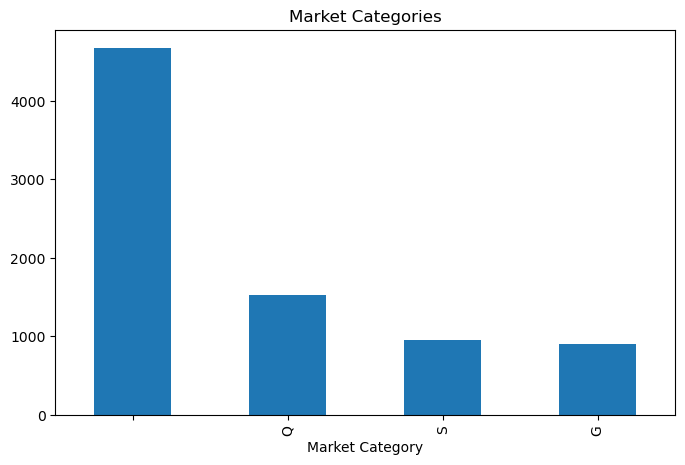

In [21]:
import matplotlib.pyplot as plt
market_counts = df['Market Category'].value_counts()

print(market_counts)

plt.figure(figsize=(8,5))
market_counts.plot(kind='bar')

plt.title("Market Categories")

plt.show()